# Preparing Vector Data for Analysis
### by [Kate Vavra-Musser](https://vavramusser.github.io) for the [R Spatial Notebook Series](https://vavramusser.github.io/r-spatial)

## Introduction
Spatial data plays a critical role in geographic information systems (GIS) and spatial analysis. However, real-world datasets often come with geometric issues such as invalid geometries, misaligned coordinates, or topology errors, which can cause errors in analysis and visualization workflows. Ensuring the validity of geometries and resolving alignment issues is a key step in preparing spatial data for analysis.

### Notebook Goals
In this notebook, we will focus the [*st_is_valid*](https://rdrr.io/cran/sf/man/valid.html), [*st_make_valid*](https://rdrr.io/cran/sf/man/valid.html), and [*st_snap*](https://rdrr.io/cran/sf/man/geos_binary_ops.html) functions from the [**sf**](https://cran.r-project.org/web/packages/sf/index.html) package. These functions help validate and repair geometries as well as align spatial features for accurate processing. By the end of this notebook, you will have a practical understanding of how to identify and fix common spatial data issues, enabling seamless integration of spatial datasets into your analysis.

### ✨ Prerequisites ✨
* Complete [Introduction to sf: Reading, Writing, and Inspecting Vector Data](https://platform.i-guide.io/notebooks/9968babe-22e4-4c3d-98e2-d8b45e9672cd)

### 💽 Data Used in this Notebook 💽
* United States State Boundaries Shapefile (*ipums_nhgis_states.shp*)
  * If you worked through [IPUMS NHGIS Data Extraction Using ipumsr: Supplemental Exercise 2](https://platform.i-guide.io/notebooks/bc79eda6-8353-42ea-8cb7-5db70aa6febf) you should have created and saved a copy of *ipums_nhgis_states.shp* in the final section of the notebook.
  * You can also download a copy of *ipums_nhgis_states.zip* file from [the I-GUIDE platform](https://platform.i-guide.io/datasets/1a5acd50-4741-447a-bf36-2331b39559af) or directly from [Kate's GitHub](https://github.com/vavramusser/r-spatial/blob/main/ipums_nhgis_states.zip).  You will need to unzip *ipums_nhgis_states.zip* and extract *ipums_nhgis_states.shp* file to your workspace.

### Notebook Overview
1. Setup
2. Validating and Repairing Geometries
3. Aligning Geometries

---

## 1. Setup
This notebook requires the following R packages and functions.

[**sf**](https://cran.r-project.org/web/packages/sf/index.html) · Support for [simple features](https://r-spatial.github.io/sf/articles/sf1.html), a standardized way to encode spatial vector data - Binds to [*GDAL*](https://gdal.org/en/stable) for reading and writing data, to [*GEOS*](https://libgeos.org) for geometrical operations, and to [*PROJ*](https://proj.org/en/stable) for projection conversions and datum transformations - Uses by default the [*s2*](https://cran.r-project.org/web/packages/s2/index.html) package for spherical geometry operations on ellipsoidal (long/lat) coordinates · This notebook uses the following functions from *sf*.

* [*geos_binary_ops*](https://rdrr.io/cran/sf/man/geos_binary_ops.html) · geometric operations on pairs of simple feature geometry sets
  * *st_snap* · snaps the vertices and segments of a geometry to another geometry's vertices
* [*valid*](https://rdrr.io/cran/sf/man/valid.html) · check validity or make an invalid geometry valid
  * *st_make_valid* · make an invalid geometry valid
  * *st_is_valid* · check validity

### 1a. Install and Load Required Packages
If you have not already installed the required packages, uncomment and run the code below:

In [1]:
# install.packages("sf")

Load the packages into your workspace.

In [2]:
library(sf)

Linking to GEOS 3.10.2, GDAL 3.4.1, PROJ 7.2.1; sf_use_s2() is TRUE



In [3]:
# read the shapefile into an sf object
states <- st_read("Chapter 2 Data/ipums_nhgis_states.shp")

Reading layer `ipums_nhgis_states' from data source 
  `C:\Users\vavra\Dropbox\R Spatial\r-spatial\02 Fundamentals of Spatial Data\Chapter 2 Data\ipums_nhgis_states.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 52 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -7115208 ymin: -1685018 xmax: 3321632 ymax: 4591848
Projected CRS: USA_Contiguous_Albers_Equal_Area_Conic


## 2. Validating and Repairing Geometries

The first step in working with spatial data is to ensure that geometries are valid. Invalid geometries can result from overlapping polygons, self-intersecting lines, or improper ring structures. The [*st_is_valid*](https://rdrr.io/cran/sf/man/valid.html) function checks for geometry validity, while [*st_make_valid*](https://rdrr.io/cran/sf/man/valid.html) attempts to fix invalid geometries.

### 2a. Checking for Invalid Geometries with [*st_is_valid*](https://rdrr.io/cran/sf/man/valid.html)

[*st_is_valid*](https://rdrr.io/cran/sf/man/valid.html) returns TRUE for valid geometries and FALSE for invalid ones.

In [4]:
#checking validity
table(st_is_valid(states))


FALSE  TRUE 
   12    40 

### 2b. Validating Invalid Geometries with [*st_make_valid*](https://rdrr.io/cran/sf/man/valid.html)

[*st_make_valid*](https://rdrr.io/cran/sf/man/valid.html) repairs geometries using robust algorithms, ensuring compatibility with spatial operations.

**NOTE:** This step may take a while.

In [5]:
# fixing invalid geometries
states_valiated <- st_make_valid(states)

In [6]:
table(st_is_valid(states_valiated))


TRUE 
  52 

## 3. Aligning Geometries

The [*st_snap*](https://rdrr.io/cran/sf/man/geos_binary_ops.html) function adjusts geometries by snapping vertices within a specified distance to a target geometry. This is particularly useful when aligning misaligned geometries or merging datasets with small offsets.  st_snap adjusts misaligned geometries within a specified tolerance distance.  It is ideal for cleaning small inconsistencies in spatial datasets.

In [7]:
# example: Aligning geometries using st_snap
target_line <- st_sfc(st_linestring(matrix(c(0, 0, 5, 5), ncol = 2, byrow = TRUE)))
misaligned_line <- st_sfc(st_linestring(matrix(c(0.2, 0, 5.2, 5.1), ncol = 2, byrow = TRUE)))

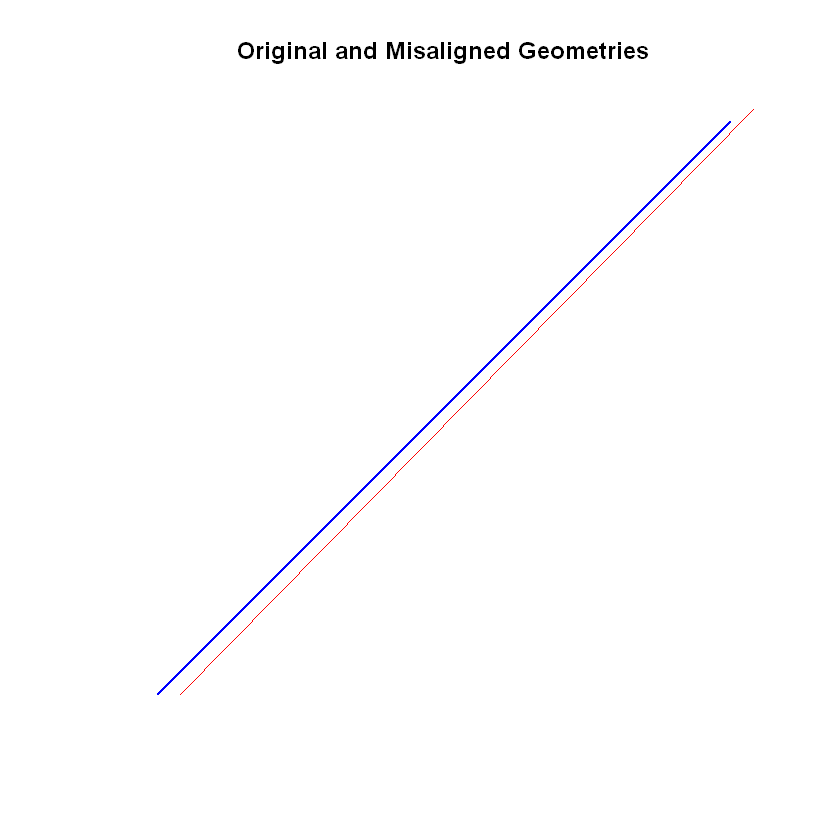

In [8]:
# visualizing original geometries
plot(target_line, col = "blue", lwd = 2, main = "Original and Misaligned Geometries")
plot(misaligned_line, col = "red", add = TRUE)

In [9]:
# snapping geometries
snapped_line <- st_snap(misaligned_line, target_line, tolerance = 0.3)

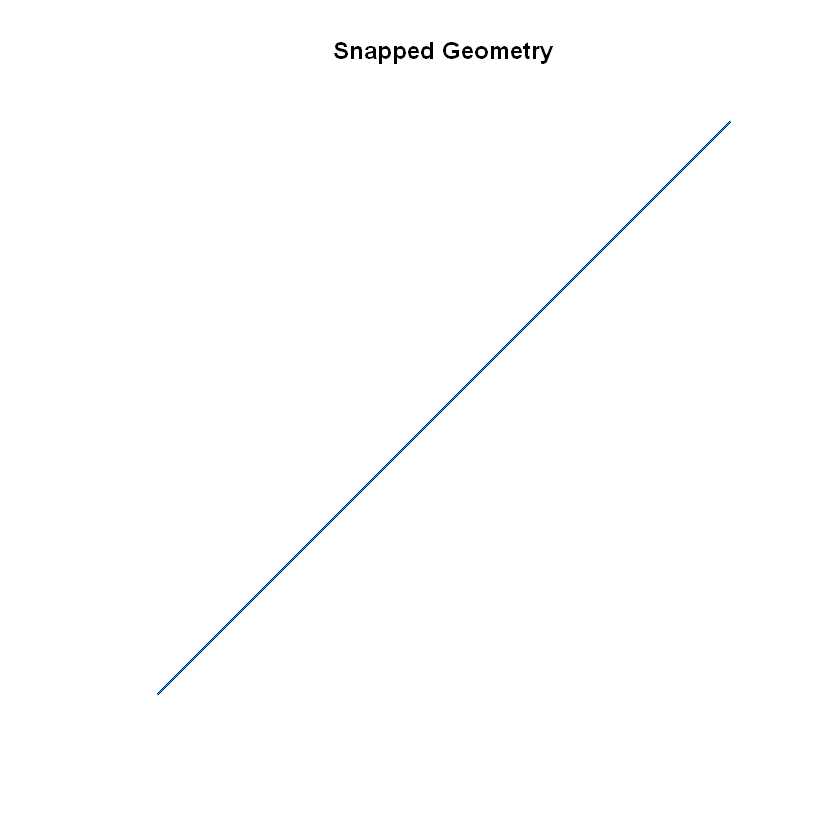

In [10]:
# visualizing snapped geometries
plot(target_line, col = "blue", lwd = 2, main = "Snapped Geometry")
plot(snapped_line, col = "green", add = TRUE)